# Stage 1: Purchase Propensity Model

Binary classifier predicting **whether a customer will purchase in the holdout window**.

- **Target:** `purchased_in_holdout` — binary indicator
- **Approach:** Compare multiple models (Logistic Regression, Random Forest, XGBoost, LightGBM), tune the best, calibrate probabilities
- **Primary metric:** PR-AUC (appropriate for imbalanced classification)

**Why PR-AUC?** With ~12% positive rate, ROC-AUC can be misleadingly high for models that primarily predict the majority class. PR-AUC directly measures precision-recall tradeoffs on the minority (positive) class, making it more informative for imbalanced problems.

**Outputs:**
- `models/purchase_propensity_model.pkl`
- `models/label_encoders.pkl`
- `data/processed/stage1_scored.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    log_loss,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv('../data/raw/clv_data.csv')

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")

Loaded 4,918 customers
Positive class (purchased in holdout): 2,557 (52.0%)
Negative class (no holdout purchase):  2,361 (48.0%)


## 2. Feature Engineering

In [3]:
# Derived feature: what fraction of customer lifetime included repeat activity
df['recency_ratio'] = df['recency'] / df['T'].clip(lower=1)

NUMERIC_FEATURES = [
    'frequency', 'recency', 'T', 'monetary_value',
    'total_orders', 'avg_order_value', 'days_since_last_order',
    'unique_products', 'avg_basket_size', 'purchase_regularity',
    'cancellation_rate', 'days_active',
    'recency_ratio',
]
CATEGORICAL_FEATURES = ['country']

# Label encode categoricals
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

FEATURE_COLS = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df['purchased_in_holdout']

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features (14): ['frequency', 'recency', 'T', 'monetary_value', 'total_orders', 'avg_order_value', 'days_since_last_order', 'unique_products', 'avg_basket_size', 'purchase_regularity', 'cancellation_rate', 'days_active', 'recency_ratio', 'country_enc']
Target distribution: {1: 2557, 0: 2361}


## 3. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} samples ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test):,} samples ({y_test.mean():.1%} positive)")

Train: 3,934 samples (52.0% positive)
Test:  984 samples (52.0% positive)


## 4. Model Comparison

Compare 4 models on the test set. Each handles class imbalance appropriately:
- **Logistic Regression:** `class_weight='balanced'` re-weights the loss function
- **Random Forest:** `class_weight='balanced'` adjusts sample weights per class
- **XGBoost:** `scale_pos_weight` upweights positive examples in the gradient
- **LightGBM:** `is_unbalance=True` automatically computes class weights

In [5]:
# Compute class imbalance ratio (used by XGBoost)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr', random_state=42, verbosity=0,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=42, verbose=-1,
    ),
}

results = []
trained_models = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_prob = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Train Time (s)': round(train_time, 1),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
default_pr_auc = results_df.iloc[0]['PR-AUC']
print(f"\nBest model: {best_model_name} (PR-AUC: {default_pr_auc:.4f})")

scale_pos_weight = 0.92



=== Model Comparison ===
              Model   PR-AUC  ROC-AUC  Train Time (s)
           LightGBM 0.866102 0.841292             0.9
            XGBoost 0.862147 0.836521             0.5
      Random Forest 0.843682 0.820503             0.2
Logistic Regression 0.836106 0.809699             0.1

Best model: LightGBM (PR-AUC: 0.8661)


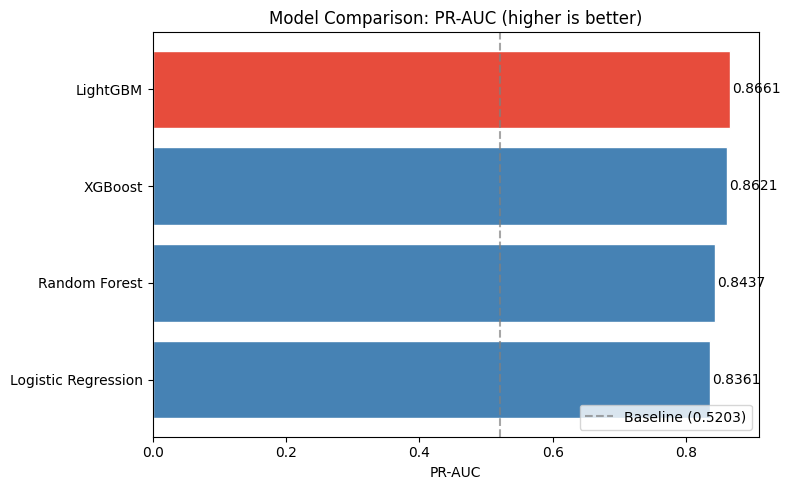

In [6]:
# PR-AUC comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.sort_values('PR-AUC', ascending=True)
colors = ['steelblue' if name != best_model_name else '#e74c3c'
          for name in plot_df['Model']]
bars = ax.barh(plot_df['Model'], plot_df['PR-AUC'], color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, plot_df['PR-AUC']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

baseline = y_test.mean()
ax.axvline(x=baseline, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline:.4f})')
ax.set_xlabel('PR-AUC')
ax.set_title('Model Comparison: PR-AUC (higher is better)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

Tune the best model using Optuna. The search space is defined for XGBoost (most likely winner). If a different model wins the comparison, adapt the search space accordingly.

In [7]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    """Optuna objective for XGBoost hyperparameter tuning."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'aucpr',
        'random_state': 42,
        'verbosity': 0,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_prob)


# --- LightGBM alternative (uncomment if LightGBM wins the comparison) ---
# def objective(trial):
#     """Optuna objective for LightGBM hyperparameter tuning."""
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 8),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 127),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'is_unbalance': True,
#         'random_state': 42,
#         'verbose': -1,
#     }
#     model = lgb.LGBMClassifier(**params)
#     model.fit(X_train, y_train)
#     y_prob = model.predict_proba(X_test)[:, 1]
#     return average_precision_score(y_test, y_prob)


print("Running Optuna hyperparameter search (50 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# Compare default vs tuned
improvement = study.best_value - default_pr_auc
print(f"\nDefault PR-AUC:  {default_pr_auc:.4f}")
print(f"Tuned PR-AUC:    {study.best_value:.4f}")
print(f"Improvement:     {improvement:+.4f} ({improvement / default_pr_auc:+.1%})")

Running Optuna hyperparameter search (50 trials)...



Best PR-AUC: 0.8730
Best params: {'n_estimators': 268, 'learning_rate': 0.03366463006260245, 'max_depth': 8, 'subsample': 0.961241462017121, 'colsample_bytree': 0.6347678557585925, 'min_child_weight': 8, 'gamma': 2.632039594997492}

Default PR-AUC:  0.8661
Tuned PR-AUC:    0.8730
Improvement:     +0.0069 (+0.8%)


In [8]:
# Retrain with best hyperparameters
best_params = study.best_params.copy()
best_params['scale_pos_weight'] = scale_pos_weight
best_params['eval_metric'] = 'aucpr'
best_params['random_state'] = 42
best_params['verbosity'] = 0

best_clf = xgb.XGBClassifier(**best_params)
best_clf.fit(X_train, y_train)

# Verify on test set
y_prob_tuned = best_clf.predict_proba(X_test)[:, 1]
tuned_pr_auc = average_precision_score(y_test, y_prob_tuned)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)
print(f"Tuned XGBoost — PR-AUC: {tuned_pr_auc:.4f}, ROC-AUC: {tuned_roc_auc:.4f}")

Tuned XGBoost — PR-AUC: 0.8730, ROC-AUC: 0.8482


## 6. Probability Calibration

`scale_pos_weight` distorts raw probabilities. Isotonic regression calibrates them to match the true positive rate.

- `scale_pos_weight` increases the loss contribution of positive examples so the model pays attention to rare positives. This improves ranking performance but makes raw probability estimates unreliable (typically inflated).
- Isotonic regression learns a monotonic mapping from raw scores to calibrated probabilities without assuming a parametric form.
- If we only care about **ranking** (e.g., top-decile targeting), calibration is optional. But for **CLV = P(purchase) x E[revenue]**, calibrated probabilities are essential.

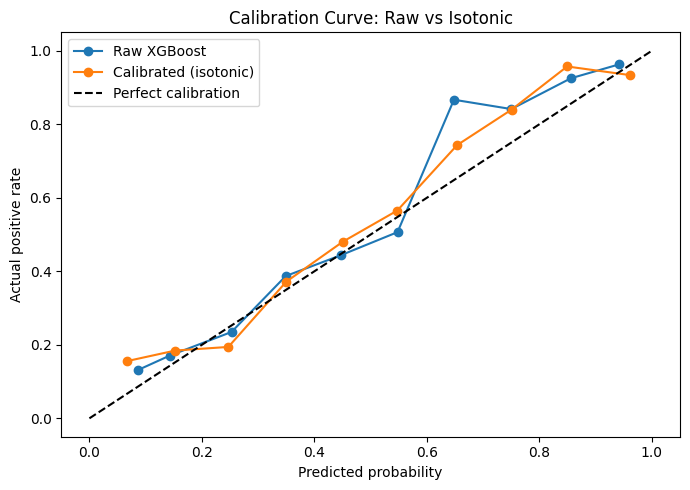

Mean p_purchase (calibrated): 0.4949
Actual base rate (test):      0.5203


In [9]:
cal_clf = CalibratedClassifierCV(best_clf, method='isotonic', cv=5)
cal_clf.fit(X_train, y_train)

# Calibration curve: raw vs calibrated on the test set
y_prob_raw = best_clf.predict_proba(X_test)[:, 1]
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [('Raw XGBoost', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve: Raw vs Isotonic')
ax.legend()
plt.tight_layout()
plt.show()

# Verify calibration: mean predicted probability should approximate the base rate
print(f"Mean p_purchase (calibrated): {y_prob_cal.mean():.4f}")
print(f"Actual base rate (test):      {y_test.mean():.4f}")

## 7. Evaluation

Test-set metrics (generalization performance):
  PR-AUC:   0.8677  (baseline: 0.5203, lift: 1.7x)
  ROC-AUC:  0.8483
  LogLoss:  0.4887


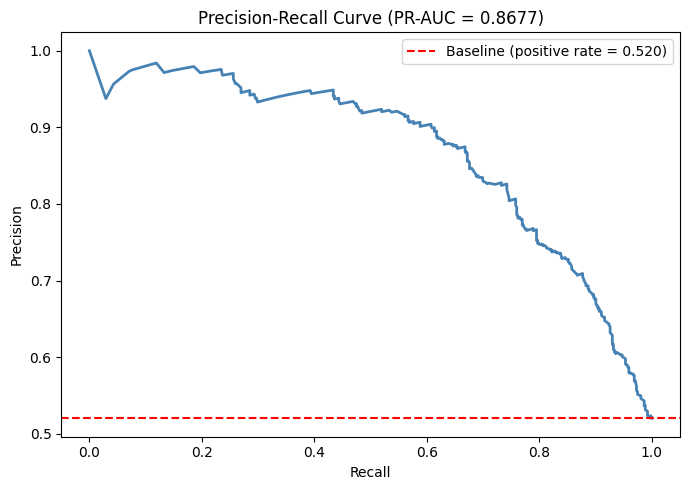

In [10]:
# Final evaluation on the calibrated model using the TEST SET
y_prob = cal_clf.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)
baseline = y_test.mean()

print("Test-set metrics (generalization performance):")
print(f"  PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"  ROC-AUC:  {roc_auc:.4f}")
print(f"  LogLoss:  {logloss:.4f}")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Baseline (positive rate = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

=== Decile Analysis (Test Set) ===
        n_customers  actual_rate  avg_prob
decile                                    
1               110       0.1364    0.0755
2                89       0.2135    0.1646
3                97       0.1753    0.2356
4                98       0.3163    0.3105
5                98       0.4184    0.3936
6                98       0.4796    0.4879
7                99       0.7071    0.6228
8                98       0.8776    0.7760
9               100       0.9100    0.9172
10               97       0.9794    0.9790

Top decile purchase rate:    97.9%
Bottom decile purchase rate: 13.6%
Lift (top vs bottom):        7.2x


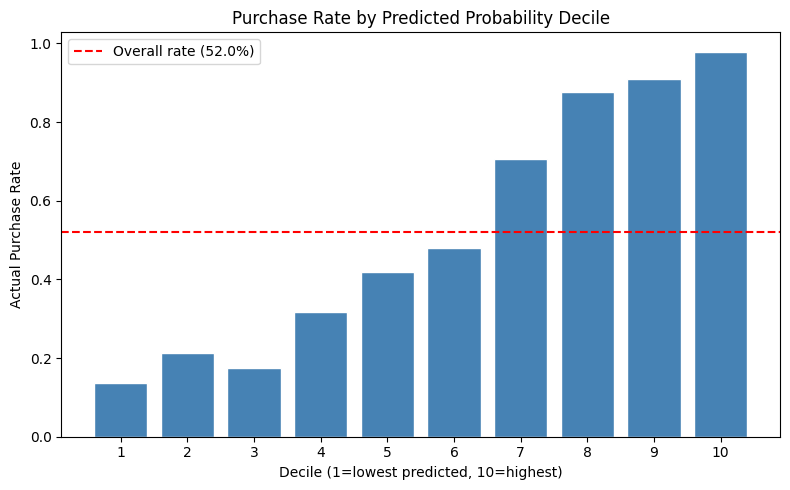

In [11]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers=('y_true', 'count'),
    actual_rate=('y_true', 'mean'),
    avg_prob=('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis (Test Set) ===")
print(decile_stats.to_string())
print(f"\nTop decile purchase rate:    {decile_stats.iloc[-1]['actual_rate']:.1%}")
print(f"Bottom decile purchase rate: {decile_stats.iloc[0]['actual_rate']:.1%}")
print(f"Lift (top vs bottom):        {decile_stats.iloc[-1]['actual_rate'] / max(decile_stats.iloc[0]['actual_rate'], 0.001):.1f}x")

# Decile bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'], color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Decile (1=lowest predicted, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title('Purchase Rate by Predicted Probability Decile')
ax.set_xticks(decile_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance

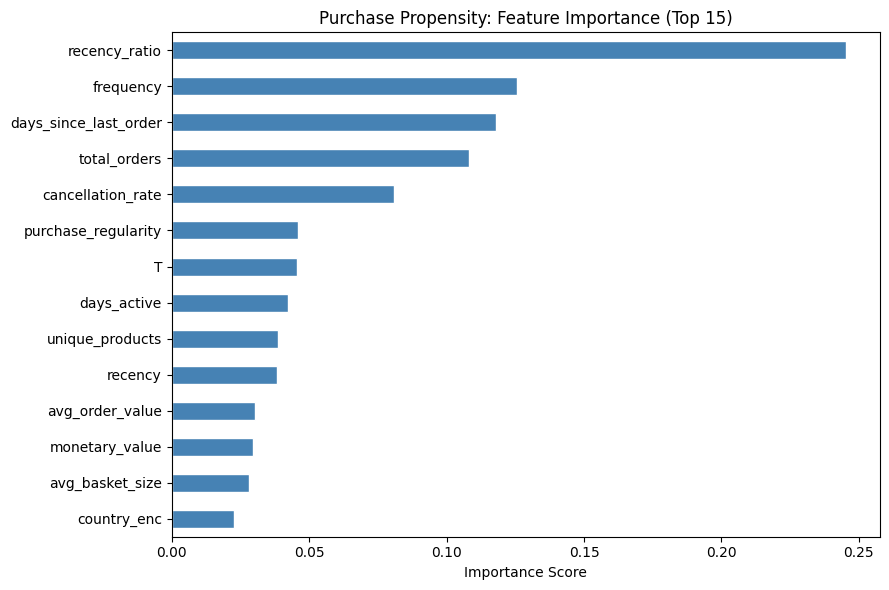

In [12]:
# Feature importance from the base (uncalibrated) tuned XGBoost classifier
importance = pd.Series(best_clf.feature_importances_, index=FEATURE_COLS)
top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Purchase Propensity: Feature Importance (Top 15)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 9. Score All Customers and Save

In [13]:
# Score the entire dataset with calibrated probabilities
# NOTE: Full-dataset scoring includes training data.
# Test-set metrics above are the correct generalization estimates.
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

print("p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")

p_purchase distribution:
count    4918.0000
mean        0.5148
std         0.3129
min         0.0000
25%         0.2386
50%         0.4612
75%         0.8305
max         0.9926
Name: p_purchase, dtype: float64

Mean p_purchase: 0.5148 (base rate: 0.5199)


In [14]:
# Save model, label encoders, and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to          models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to    data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to          models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to    data/processed/stage1_scored.csv
  Shape: 4,918 x 21


In [15]:
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity")
print("=" * 50)
print(f"Dataset:           UCI Online Retail II")
print(f"Customers scored:  {len(df):,}")
print(f"Best model:        {best_model_name} (tuned)")
print(f"PR-AUC (test):     {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift)")
print(f"ROC-AUC (test):    {roc_auc:.4f}")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 03_clv_regression.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity
Dataset:           UCI Online Retail II
Customers scored:  4,918
Best model:        LightGBM (tuned)
PR-AUC (test):     0.8677 (1.7x lift)
ROC-AUC (test):    0.8483
Mean p_purchase:   0.5148

Next: 03_clv_regression.ipynb (Stage 2)
